In [6]:
from netCDF4 import Dataset
import datetime
import warnings
import matplotlib
import pandas as pd
import os
import numpy as np
from scipy.signal import argrelextrema
import pickle
import warnings
import matplotlib.pyplot as plt
# import sys
# sys.path.append('/home/robbie/custom_modules/')
from ll_xy import lonlat_to_xy
import kuka_tools as kt
# You can find kuka_tools at https://github.com/robbiemallett/custom_modules/blob/master/kuka_tools.py

In [7]:
directory = '/home/robbie/Dropbox/kuka_slush/data/kuka/20231003'

freqs=['ku','ka']
listfiles = os.listdir(directory)

files = {'ku':sorted([f for f in listfiles if f'Ku-Scat' in f]),
         'ka':sorted([f for f in listfiles if f'Ka-Scat' in f])}

files

{'ku': ['kuka_stare_decon_Ku-Scat20231003-103408.nc',
  'kuka_stare_decon_Ku-Scat20231003-103908.nc',
  'kuka_stare_decon_Ku-Scat20231003-132908.nc',
  'kuka_stare_decon_Ku-Scat20231003-133409.nc'],
 'ka': ['kuka_stare_decon_Ka-Scat20231003-103603.nc',
  'kuka_stare_decon_Ka-Scat20231003-104103.nc',
  'kuka_stare_decon_Ka-Scat20231003-133103.nc',
  'kuka_stare_decon_Ka-Scat20231003-133603.nc']}

In [8]:
d = Dataset(f'{directory}/kuka_stare_decon_Ku-Scat20231003-133409.nc')

In [9]:
files['afternoon'] =  ['kuka_stare_decon_Ka-Scat20231003-133103.nc',
                      'kuka_stare_decon_Ka-Scat20231003-133603.nc',
                       ]

files['morning'] = ['kuka_stare_decon_Ka-Scat20231003-103603.nc',
                    'kuka_stare_decon_Ka-Scat20231003-104103.nc',
                  ]


Start Time in % of wfms
44.060239360163465
End Time in % of wfms
90.19435147825467


/tmp/ipykernel_5509/3299033878.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  time=list(np.array(Dataset(f'{directory}/{f}')['start_time']))
/tmp/ipykernel_5509/3299033878.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, 'y distance (m)')

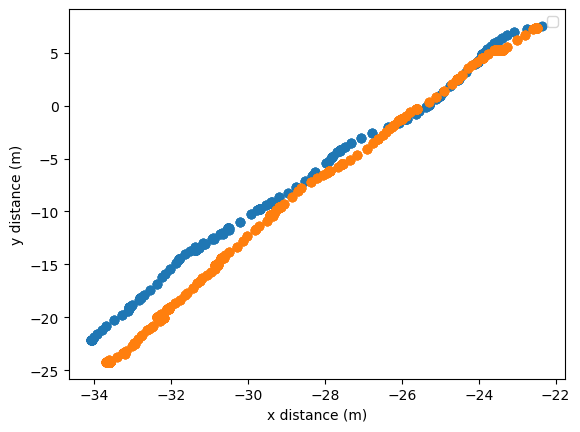

In [45]:
fig,ax = plt.subplots(1,1)

# x,y=kt.plot_pos(files['afternoon'][0],directory,plot=False)    

x0 = -2300414.994491106; y0 = 923485.871699531

x_=[]
y_=[]
t=[]

for f in files['afternoon']:

    x,y = kt.plot_pos(f,directory,x0=x0,y0=y0,plot=False)
    time=list(np.array(Dataset(f'{directory}/{f}')['start_time']))
    x_+=list(x)
    y_+=list(y)
    t+=time

start,end=1020,-228

start_pc=100*(t[1020]-t[0])/(t[-1]-t[0])
end_pc=100*(t[-228]-t[0])/(t[-1]-t[0])
print('Start Time in % of wfms')
print(start_pc)
print('End Time in % of wfms')
print(end_pc)

plt.scatter(x_[start:end],y_[start:end])

x_=[]
y_=[]

for f in files['morning']:

    x,y = kt.plot_pos(f,directory,x0=x0,y0=y0,plot=False)
    x_+=list(x)
    y_+=list(y)

plt.scatter(x_,y_)
    
ax.legend()
ax.set_xlabel('x distance (m)')
ax.set_ylabel('y distance (m)')

In [33]:
pickle.dump((x_,y_),open('clip.p','wb'))